<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = sns.load_dataset('titanic')
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Data Cleaning Process

In [ ]:
df = df.drop(['survived', 'pclass', 'embarked', 'deck','alone'], axis=1)
display(df.head())

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no


ckeck how many columns have null values and fill the values

In [ ]:
df.isnull().sum()

,0
sex,0
age,177
sibsp,0
parch,0
fare,0
class,0
who,0
adult_male,0
embark_town,2
alive,0


In [ ]:
mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age)

In [ ]:
mode_embark_town = df['embark_town'].mode()[0]
df['embark_town'] = df['embark_town'].fillna(mode_embark_town)
display(df.isnull().sum())

,0
sex,0
age,0
sibsp,0
parch,0
fare,0
class,0
who,0
adult_male,0
embark_town,0
alive,0


In [ ]:
df.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no


Statistics value of Data

In [ ]:
df.describe()

,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,13.002015,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,29.699118,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   sex          891 non-null    object  
 1   age          891 non-null    float64 
 2   sibsp        891 non-null    int64   
 3   parch        891 non-null    int64   
 4   fare         891 non-null    float64 
 5   class        891 non-null    category
 6   who          891 non-null    object  
 7   adult_male   891 non-null    bool    
 8   embark_town  891 non-null    object  
 9   alive        891 non-null    object  
dtypes: bool(1), category(1), float64(2), int64(2), object(4)
memory usage: 57.7+ KB


Respresents the sex Distribution

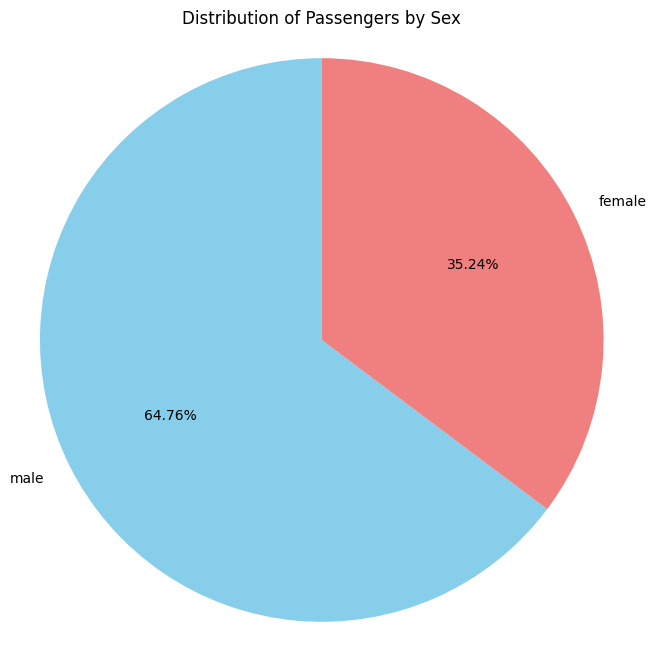

In [ ]:
sex_counts = df['sex'].value_counts()
sex_percentages = sex_counts / sex_counts.sum() * 100

plt.figure(figsize=(8, 8))
plt.pie(sex_percentages, labels=sex_percentages.index, autopct='%1.2f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Passengers by Sex')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Distribution of Passengers by Survival

/tmp/ipython-input-1976279962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='alive', data=df, palette='viridis')


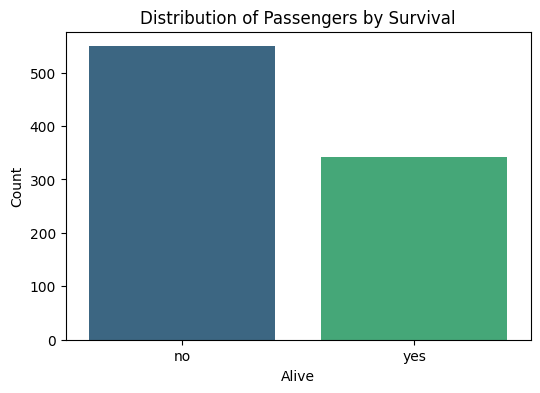

In [ ]:
alive_counts = df['alive'].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(x='alive', data=df, palette='viridis')
plt.title('Distribution of Passengers by Survival')
plt.xlabel('Alive')
plt.ylabel('Count')
plt.show()

Distribution of Passengers by Age Group (10-year intervals)

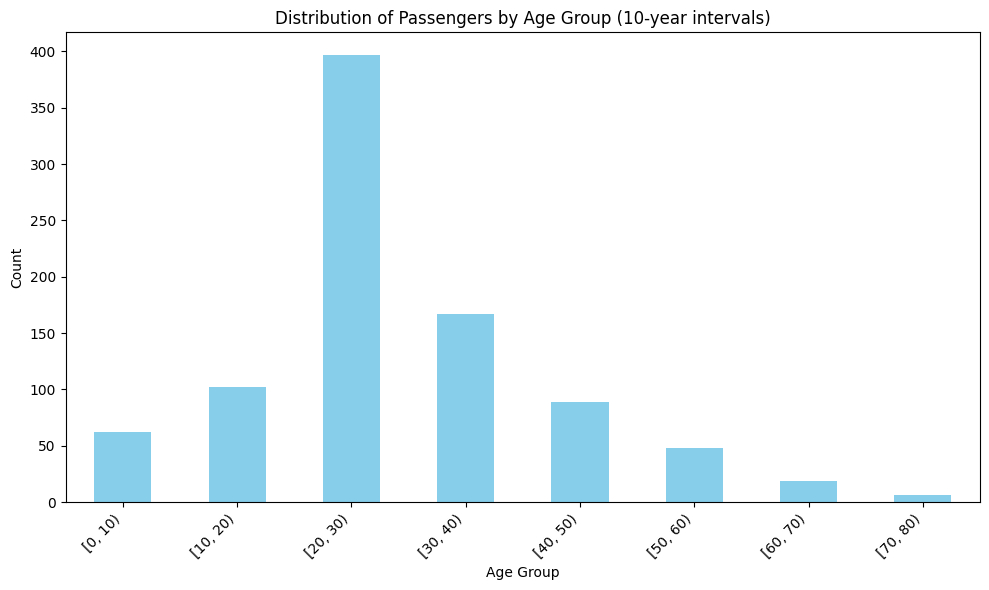

In [ ]:
# Create age bins
age_bins = range(0, int(df['age'].max()) + 10, 10)
df['age_group'] = pd.cut(df['age'], bins=age_bins, right=False)

# Count the occurrences in each age bin
age_group_counts = df['age_group'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
age_group_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Passengers by Age Group (10-year intervals)')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,age_group
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,"[20, 30)"
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,"[30, 40)"
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,"[20, 30)"
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,"[30, 40)"
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,"[30, 40)"


Distribution of Passengers by Category (Man, Woman, Child)

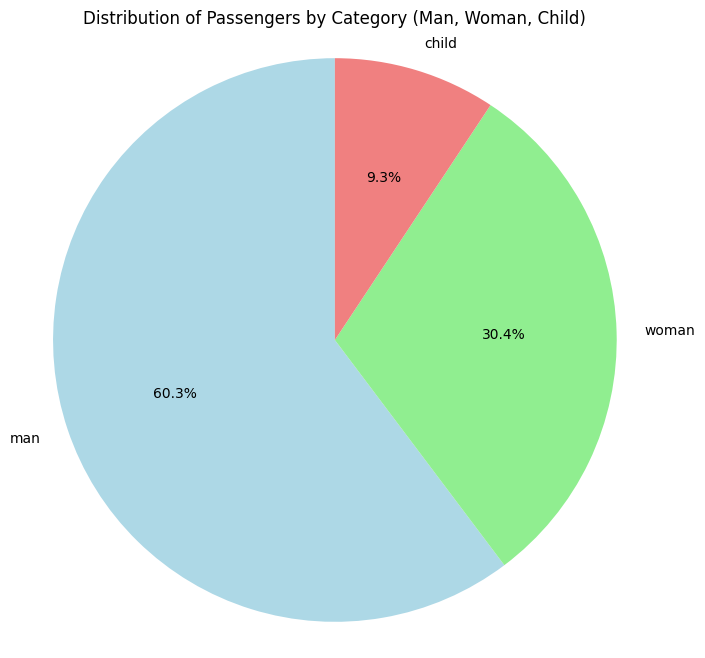

In [ ]:
who_counts = df['who'].value_counts()
who_percentages = who_counts / who_counts.sum() * 100

plt.figure(figsize=(8, 8))
plt.pie(who_percentages, labels=who_percentages.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('Distribution of Passengers by Category (Man, Woman, Child)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Distribution of Male and Female Children

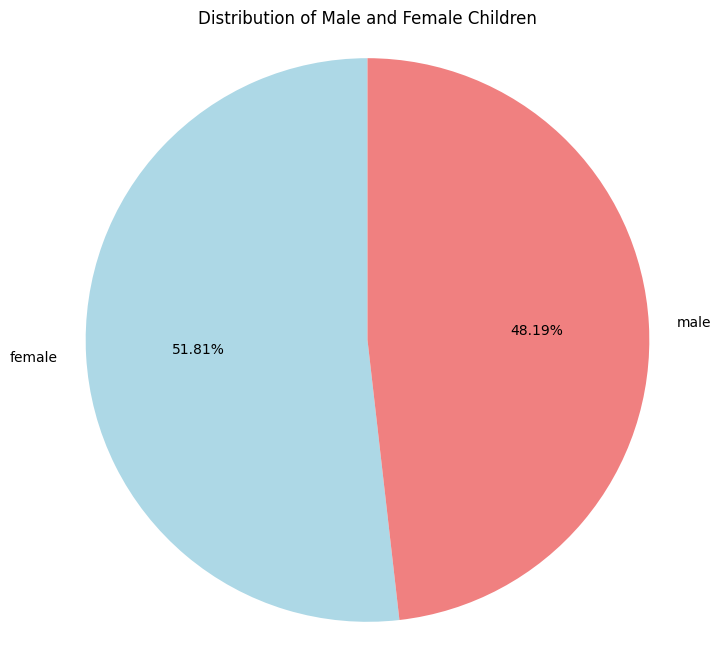

In [ ]:
children_df = df[df['who'] == 'child']
child_sex_counts = children_df['sex'].value_counts()
child_sex_percentages = child_sex_counts / child_sex_counts.sum() * 100

plt.figure(figsize=(8, 8))
plt.pie(child_sex_percentages, labels=child_sex_percentages.index, autopct='%1.2f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title('Distribution of Male and Female Children')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Survival Distribution by Category (Man, Woman, Child)

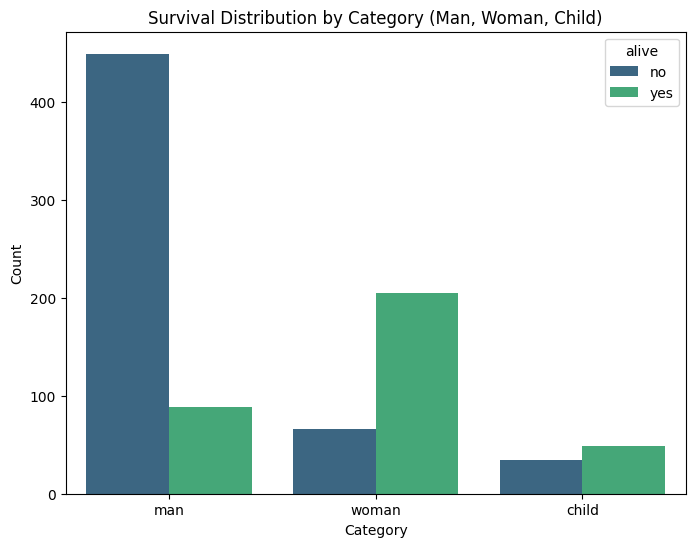

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='who', hue='alive', data=df, palette='viridis')
plt.title('Survival Distribution by Category (Man, Woman, Child)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

Distribution of Passengers by Class

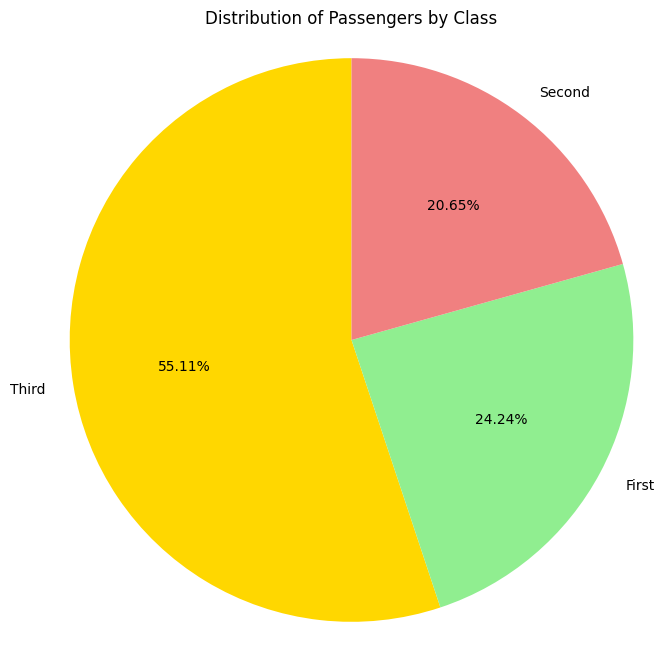

In [ ]:
class_counts = df['class'].value_counts()
class_percentages = class_counts / class_counts.sum() * 100

plt.figure(figsize=(8, 8))
plt.pie(class_percentages, labels=class_percentages.index, autopct='%1.2f%%', startangle=90, colors=['gold', 'lightgreen', 'lightcoral'])
plt.title('Distribution of Passengers by Class')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Distribution of Passengers by Embarkation Town

/tmp/ipython-input-3099834310.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='embark_town', data=df, palette='viridis')


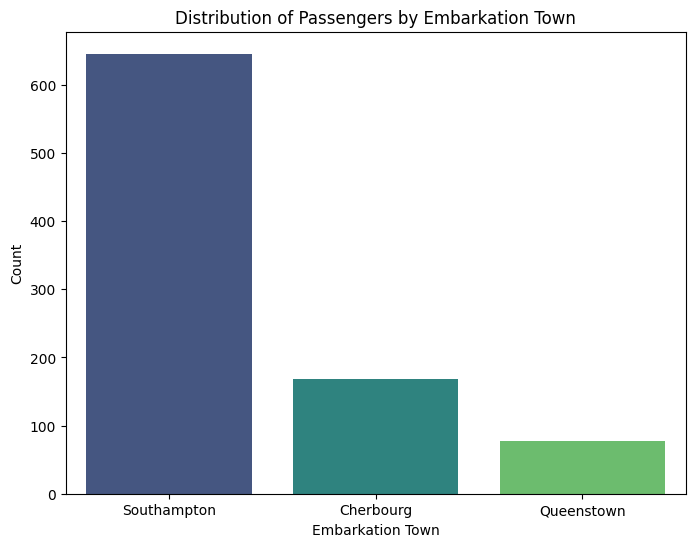

In [ ]:
embark_town_counts = df['embark_town'].value_counts()

plt.figure(figsize=(8, 6))
sns.countplot(x='embark_town', data=df, palette='viridis')
plt.title('Distribution of Passengers by Embarkation Town')
plt.xlabel('Embarkation Town')
plt.ylabel('Count')
plt.show()

Distribution of Passenger Class by Embarkation Town

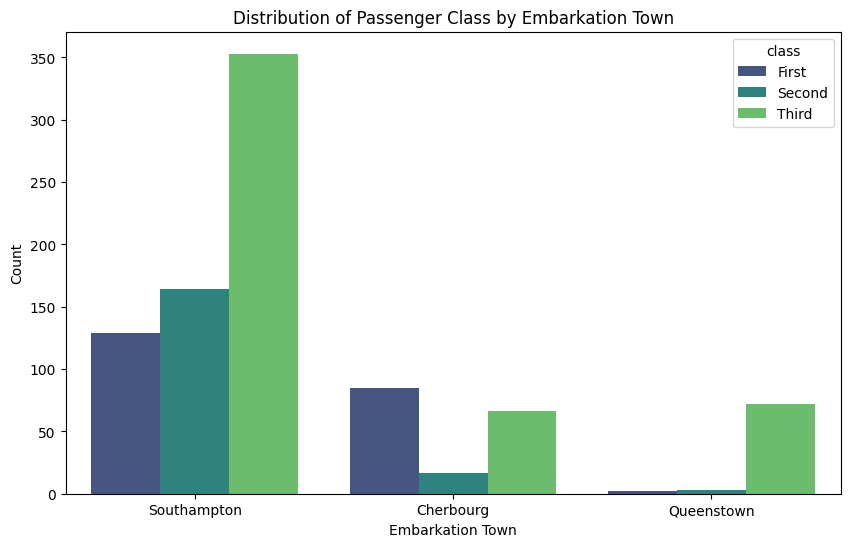

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='embark_town', hue='class', palette='viridis')
plt.title('Distribution of Passenger Class by Embarkation Town')
plt.xlabel('Embarkation Town')
plt.ylabel('Count')
plt.show()

Total Siblings/Spouses and Parents/Children Aboard

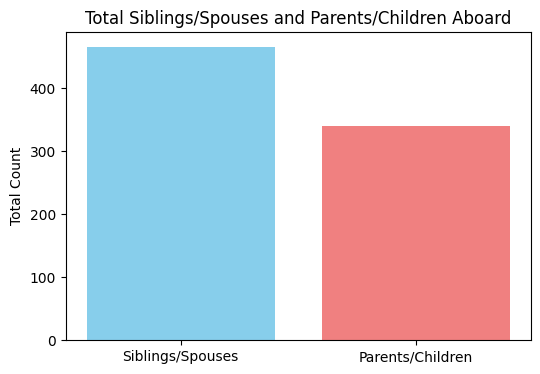

In [ ]:
sibsp_sum = df['sibsp'].sum()
parch_sum = df['parch'].sum()

# Create a bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Siblings/Spouses', 'Parents/Children'], [sibsp_sum, parch_sum], color=['skyblue', 'lightcoral'])
plt.title('Total Siblings/Spouses and Parents/Children Aboard')
plt.ylabel('Total Count')
plt.show()

Survival Distribution by Age Group and also Survival Distribution by Embarkation Town

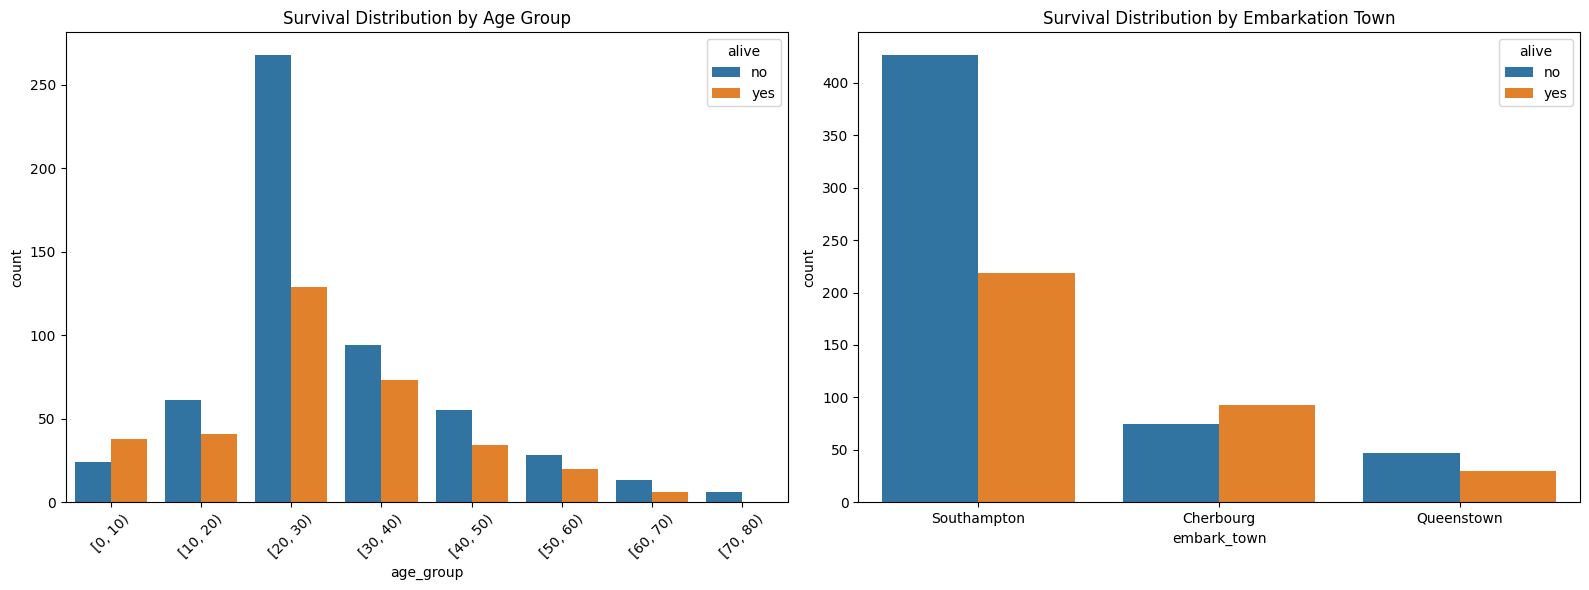

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(ax=axes[0], x='age_group', hue='alive', data=df)
axes[0].set_title('Survival Distribution by Age Group')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[1], x='embark_town', hue='alive', data=df)
axes[1].set_title('Survival Distribution by Embarkation Town')

plt.tight_layout()
plt.show()

Distribution of Passengers by Class

In [ ]:
average_fare_by_class = df.groupby('class')['fare'].mean()
display(average_fare_by_class)

/tmp/ipython-input-455632143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_fare_by_class = df.groupby('class')['fare'].mean()


,fare
class,
First,84.154687
Second,20.662183
Third,13.675550


###Summary

This notebook analyzes the Titanic dataset. Here's a breakdown of the main steps:

->  Data Cleaning Process: We loaded the data, removed some columns, and filled in missing values for age and embarkation town.

->  Statistics value of Data: We looked at the descriptive statistics and information about the dataset to understand the data types and non-null counts.

->  Visualizations: We created various charts to visualize different aspects of the data:

    -> Distribution of Passengers by Sex
    -> Distribution of Passengers by Survival
    -> Distribution of Passengers by Age Group (10-year intervals)
    -> Distribution of Passengers by Category (Man, Woman, Child)
    -> Distribution of Male and Female Children
    -> Survival Distribution by Category (Man, Woman, Child)
    -> Distribution of Passengers by Class
    -> Distribution of Passengers by Embarkation Town
    -> Distribution of Passenger Class by Embarkation Town
    -> Total Siblings/Spouses and Parents/Children Aboard
    -> Survival Distribution by Age Group and also Survival Distribution by Embarkation Town
-> Analysis: We calculated the average fare for each passenger class.
These steps helped us understand the characteristics of the passengers and factors related to their survival.